# Arsenal Match — results overview

This notebook **reads the committed results back**; it trains nothing, downloads nothing, and computes no
new number. Every table below is loaded from `docs/results/`, which the pipeline scripts write (see
`docs/results/README.md` for the index and `SETUP.md` for how to regenerate them).

The order is the order of the project: question → data → preprocessing → model → experiment → results →
what it means.

AI assistance: drafted with Claude Code (Anthropic); reviewed, run, and modified by Toma Shigaki-Than.
See ATTRIBUTION.md.

In [1]:
import json
from pathlib import Path

import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RESULTS = ROOT / "docs" / "results"
FIGURES = ROOT / "docs" / "figures"
pd.set_option("display.width", 160)


def load(name):
    """Read one committed result table."""
    return pd.read_csv(RESULTS / name)


print(sorted(p.name for p in RESULTS.glob("*.csv"))[:8], "...")

['ablation.csv', 'ablation_summary.csv', 'alpha_sweep_test.csv', 'alpha_sweep_val.csv', 'baseline_deltas_test.csv', 'baseline_deltas_val.csv', 'calibration_test.csv', 'calibration_val.csv'] ...


## 1. The question

Pitcher-similarity tools define "similar" by hand — pick some measurements, weight them, compute a
distance — and none of them reports whether that definition predicts anything.

**Can a similarity metric learned from pitch outcomes pick better comps than hand-built physical
similarity?** "Better" has one meaning here: for a pitcher held out of training, do his 10 nearest comps'
actual results predict his?

## 2. The data

Every regular-season MLB pitch from 2023 to 2026, pulled from Baseball Savant one month at a time
(`src/data/fetch_statcast.py`). The split is by season, never random: a random split would put the same
pitcher on both sides and measure memorization.

In [2]:
summary = load("data_summary.csv")

print("Rows in and out:")
print(summary[summary["section"] == "load"].to_string(index=False))

print("\nSplit by season (train 2023-24, validate 2025, test 2026):")
split = summary[summary["section"].isin(["split_pitches", "split_pitch_share", "split_pitcher_seasons"])]
print(split.pivot(index="item", columns="section", values="value").to_string())

Rows in and out:
section         item     value
   load  raw pitches 2955003.0
   load pitches kept 2814234.0

Split by season (train 2023-24, validate 2025, test 2026):
section  split_pitch_share  split_pitcher_seasons  split_pitches
item                                                            
test                0.2459                  809.0       691998.0
train               0.5037                 1606.0      1417523.0
val                 0.2504                  803.0       704713.0


## 3. Preprocessing

Eight filter stages remove what isn't a usable, competitive, tracked pitch from a real pitcher. Each stage
prints and saves how many rows it dropped, so the cleaning is auditable rather than asserted.

In [3]:
print("Pitches removed by each filter stage:")
print(summary[summary["section"] == "filter_removed"][["item", "value"]].to_string(index=False))

print("\nEach surviving pitch gets one of seven outcome labels:")
shares = summary[summary["section"] == "label7_share"][["item", "value"]]
print(shares.assign(share=lambda d: (100 * d["value"]).round(1).astype(str) + "%")[["item", "share"]]
      .to_string(index=False))

Pitches removed by each filter stage:
                                    item    value
                     regular season only 109491.0
    valid count (0-3 balls, 0-2 strikes)      0.0
pitch-clock violations (no pitch thrown)   9838.0
      bunt attempts (author's call, D13)  10964.0
     missing pitch type or core tracking   1240.0
      KN / EP / FA / PO / UN pitch types   8451.0
    position players pitching (statsapi)    785.0

Each surviving pitch gets one of seven outcome labels:
         item share
called_strike 16.4%
         ball 36.1%
        whiff 12.2%
         foul 18.1%
         poor 10.5%
        flare  4.2%
       damage  2.5%


## 4. The model

An arsenal is a **set** of pitch types — no order, and between 2 and 9 of them — so the encoder is a Deep
Sets network: the same small network runs on every pitch type, the results are pooled by usage weight, and
one more layer maps that to the embedding. The embedding learns by helping predict each individual pitch's
outcome, plus an auxiliary head that sees *only* the embedding, so the retrieval space can't be bypassed.

The cell below loads the shipped checkpoint to read its shape. It runs no data through the model.

In [4]:
import torch

ckpt = torch.load(ROOT / "models" / "arsenal_net_t1.pt", map_location="cpu", weights_only=False)
n_params = sum(t.numel() for t in ckpt["state_dict"].values())

print(f"tier {ckpt['tier']}, embedding size {ckpt['config']['d_emb']}, {n_params:,} parameters")
print(f"arsenal features per pitch type: {ckpt['d_arsenal']}; per-pitch features: {ckpt['d_pitch']}")
print(f"outcome classes: {ckpt['classes']}")
print(f"published run: {json.loads((ROOT / 'models' / 'published.json').read_text())}")

tier t1, embedding size 8, 34,519 parameters
arsenal features per pitch type: 19; per-pitch features: 34
outcome classes: ['called_strike', 'ball', 'whiff', 'foul', 'poor', 'flare', 'damage']
published run: {'t1': 't1_emb8_profile_s372', 't3a': 't3a_emb8_profile_s372'}


### What was chosen, and on what

Both choices below were made on **2025 only**. Configs are compared on the mean over three seeds, because
the same seed can give different numbers on Apple's GPU; a config within one seed-SD of the top counts as
tied and the lower error wins.

In [5]:
sweep = load("sweep_summary.csv")
print("Embedding-size sweep (2025, mean +- SD over 3 seeds):")
print(sweep[["d_emb", "val_retrieval_r_mean", "val_retrieval_r_std", "val_retrieval_mae_mean", "selected"]]
      .round(4).to_string(index=False))

ablation = load("ablation_summary.csv")
print("\nAblation: input tier x auxiliary target (2025, mean +- SD over 3 seeds):")
print(ablation[["tier", "aux", "val_retrieval_r_mean", "val_retrieval_r_std", "val_retrieval_mae_mean",
                "selected"]].round(4).to_string(index=False))

Embedding-size sweep (2025, mean +- SD over 3 seeds):
 d_emb  val_retrieval_r_mean  val_retrieval_r_std  val_retrieval_mae_mean  selected
     8                0.2246               0.0197                  0.7782      True
    16                0.2197               0.0497                  0.7785     False
    32                0.1735               0.0444                  0.7849     False

Ablation: input tier x auxiliary target (2025, mean +- SD over 3 seeds):
tier        aux  val_retrieval_r_mean  val_retrieval_r_std  val_retrieval_mae_mean  selected
  t1 profile_rv                0.2246               0.0197                  0.7782     False
  t1        off                0.1749               0.0123                  0.7859     False
  t1    profile                0.2238               0.0144                  0.7678      True
 t3a        off                0.1817               0.0192                  0.7811     False
 t3a    profile                0.1911               0.0189             

## 5. The experiment

One protocol, every method. For each pitcher-season with at least 300 pitches, take the 10 most similar
*other* pitchers from the same season, hand and role, and predict his run value per 100 pitches as the plain
mean of theirs. Score with Pearson r and mean absolute error, against a no-similarity baseline: the mean of
his whole candidate pool.

Confidence intervals come from a paired bootstrap over query pitchers (B = 2000) — the same resamples for
every method, so the difference between two methods has its own interval.

In [6]:
cols = ["method", "r", "r_lo", "r_hi", "mae", "delta_r", "delta_r_lo", "delta_r_hi"]
for split_name, season in [("val", 2025), ("test", 2026)]:
    mc = load(f"method_comparison_{split_name}.csv")
    print(f"RV/100, {season} ({'validation' if split_name == 'val' else 'test, scored once'}); "
          f"deltas vs. {mc['reference'].iloc[0]}, n = {mc['n_queries'].iloc[0]}")
    print(mc[cols].round(3).to_string(index=False))
    print(f"no-similarity baseline MAE: {mc['baseline_mae'].iloc[0]:.3f}\n")

RV/100, 2025 (validation); deltas vs. hzb, n = 573
     method     r   r_lo  r_hi   mae  delta_r  delta_r_lo  delta_r_hi
        raw 0.052 -0.029 0.130 0.800   -0.093      -0.188       0.004
    tjstats 0.033 -0.049 0.117 0.820   -0.112      -0.201      -0.016
        hzb 0.145  0.072 0.215 0.810    0.000       0.000       0.000
       seam 0.048 -0.032 0.130 0.812   -0.096      -0.179      -0.013
    learned 0.240  0.167 0.315 0.764    0.096       0.011       0.180
learned_t3a 0.209  0.132 0.288 0.774    0.065      -0.015       0.152
  blend_1.0 0.240  0.167 0.315 0.764    0.096       0.011       0.180
no-similarity baseline MAE: 0.786

RV/100, 2026 (test, scored once); deltas vs. hzb, n = 557
     method     r   r_lo  r_hi   mae  delta_r  delta_r_lo  delta_r_hi
        raw 0.038 -0.048 0.127 0.764   -0.126      -0.230      -0.015
    tjstats 0.081 -0.002 0.165 0.755   -0.082      -0.177       0.010
        hzb 0.163  0.073 0.245 0.744    0.000       0.000       0.000
       seam 0.05

## 6. Results

One number per method hides what each kind of similarity is good at, so the same test runs on seven stats.
Split-half reliability is in the first column: it is the ceiling any method could reach on that stat, and
RV/100's is low enough that every correlation below should be read against it.

In [7]:
for split_name, season in [("val", 2025), ("test", 2026)]:
    bd = load(f"stat_breakdown_{split_name}.csv")
    rel = load(f"stat_reliability_{split_name}.csv").set_index("stat")["reliability"]
    wide = bd.pivot_table(index="stat", columns="method", values="r")
    learned = bd[bd["method"] == "learned"].set_index("stat")[["delta_r", "delta_r_lo", "delta_r_hi"]]
    table = wide.join(rel.rename("reliability")).join(learned).reindex(rel.index)
    print(f"{season}: r by stat and method, with learned - {bd['reference'].iloc[0]}")
    print(table.round(3).to_string(), "\n")

2025: r by stat and method, with learned - hzb
                 hzb  learned    raw   seam  tjstats  reliability  delta_r  delta_r_lo  delta_r_hi
stat                                                                                              
pitcher_rv100  0.145    0.240  0.052  0.048    0.033        0.279    0.096       0.011       0.180
k_pct          0.402    0.537  0.214  0.288    0.332        0.698    0.135       0.066       0.206
bb_pct         0.178    0.333  0.138  0.186    0.108        0.444    0.155       0.066       0.245
whiff_pct      0.406    0.597  0.297  0.367    0.360        0.781    0.191       0.130       0.251
chase_pct      0.127    0.207  0.064 -0.013    0.042        0.515    0.080      -0.021       0.184
gb_pct         0.640    0.472  0.270  0.450    0.510        0.733   -0.168      -0.229      -0.108
damage_pct     0.342    0.253  0.192  0.211    0.218        0.250   -0.090      -0.163      -0.021 

2026: r by stat and method, with learned - hzb
             

In [8]:
sl = load("slices_test.csv")
print("2026 slices, RV/100 r (the out-of-distribution check the app is built for is 'new'):")
print(sl.pivot_table(index="slice", columns="method", values="r").round(3).to_string())

cal = load("calibration_test.csv")
print("\n2026 calibration of the pitch-outcome head (ECE per class, and log loss vs. the class prior):")
print(cal.round(4).to_string(index=False))

2026 slices, RV/100 r (the out-of-distribution check the app is built for is 'new'):
method                                   hzb  learned  learned_t3a    raw   seam  tjstats
slice                                                                                    
FB velo bottom quartile (< 92.5 mph)   0.024    0.065       -0.126 -0.073 -0.153    0.012
FB velo top 3 quartiles (>= 92.5 mph)  0.179    0.188        0.190  0.085  0.109    0.081
new (not in 2023-24 training)          0.148    0.046        0.101 -0.020  0.042    0.131
seen in 2023-24 training               0.171    0.222        0.164  0.054  0.054    0.062

2026 calibration of the pitch-outcome head (ECE per class, and log loss vs. the class prior):
                 curve    ece  mean_pred  obs_freq
         called_strike 0.0021     0.1649    0.1629
                  ball 0.0072     0.3630    0.3630
                 whiff 0.0031     0.1223    0.1201
                  foul 0.0037     0.1795    0.1820
                  poor 0.

training_curves.png


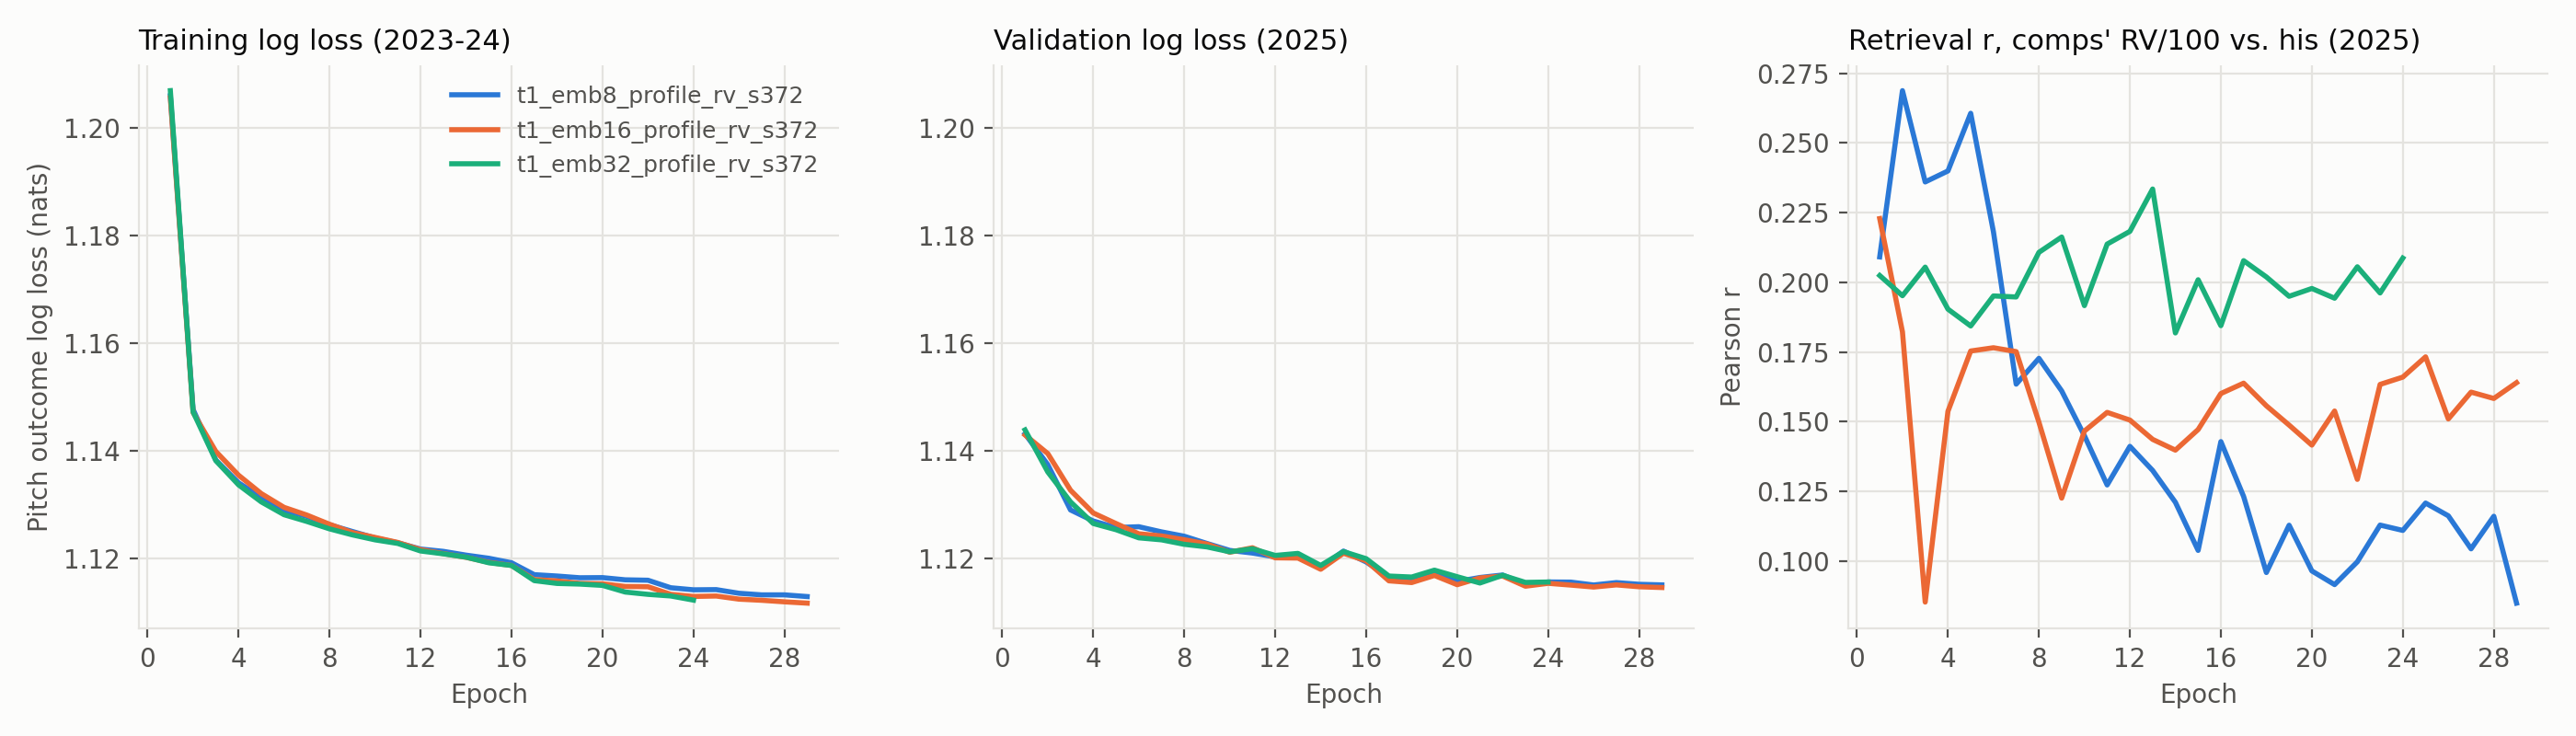

stat_breakdown_test.png


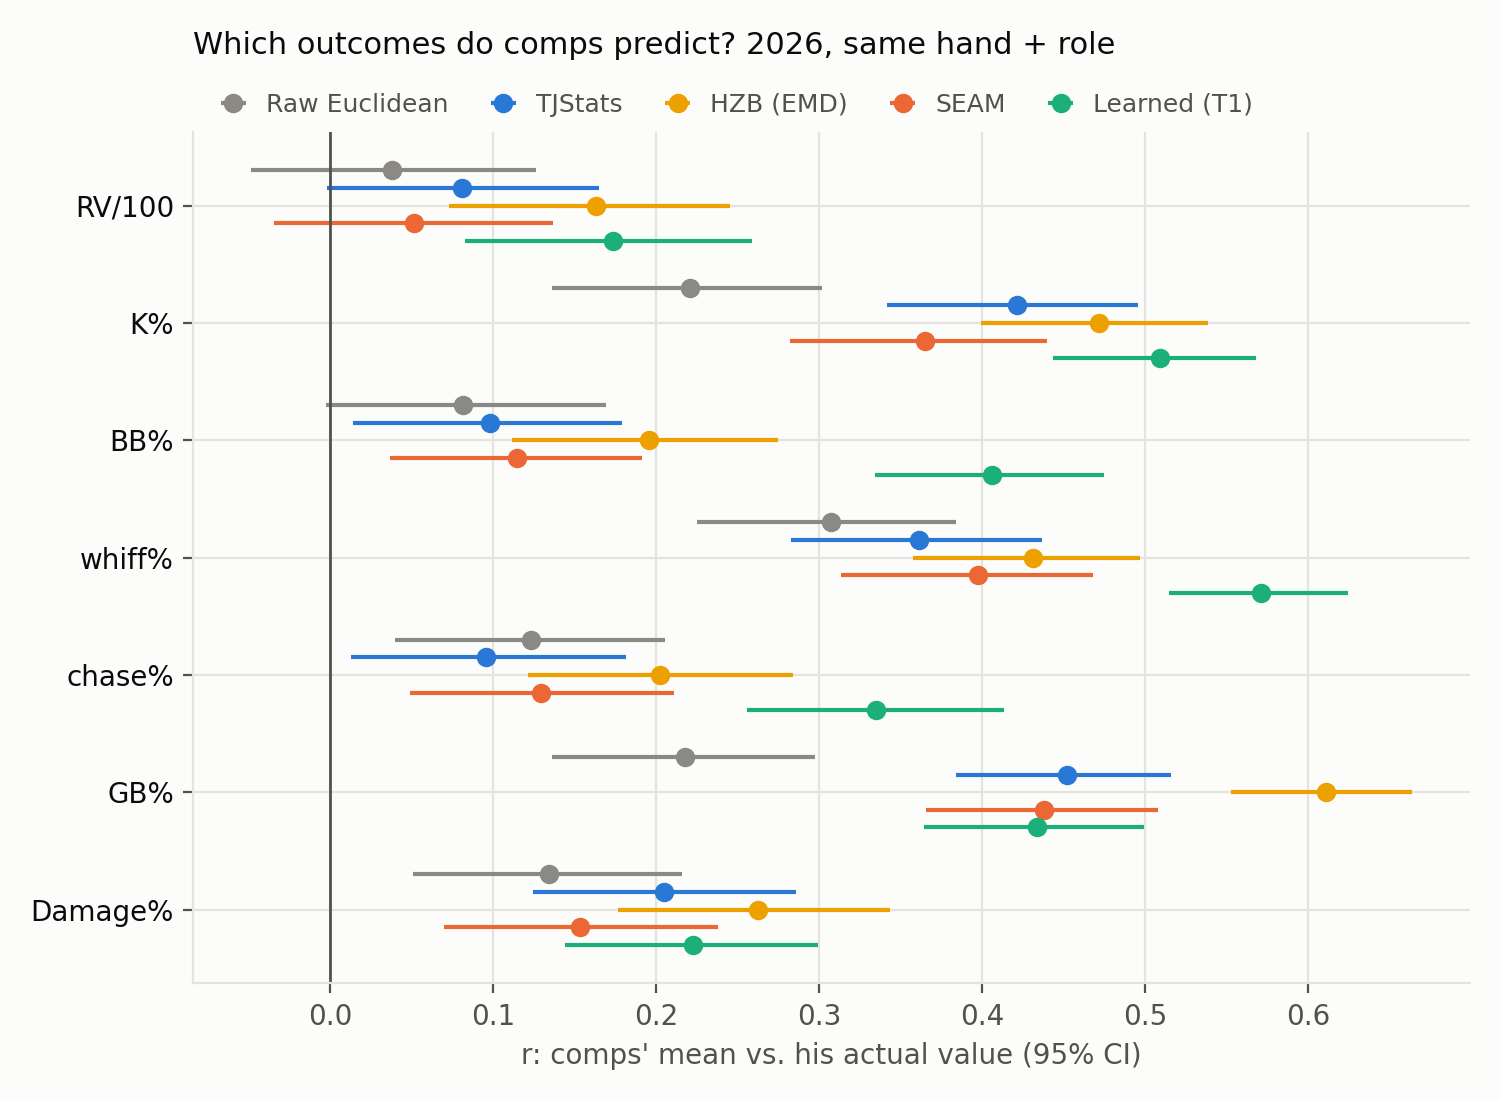

reliability_test.png


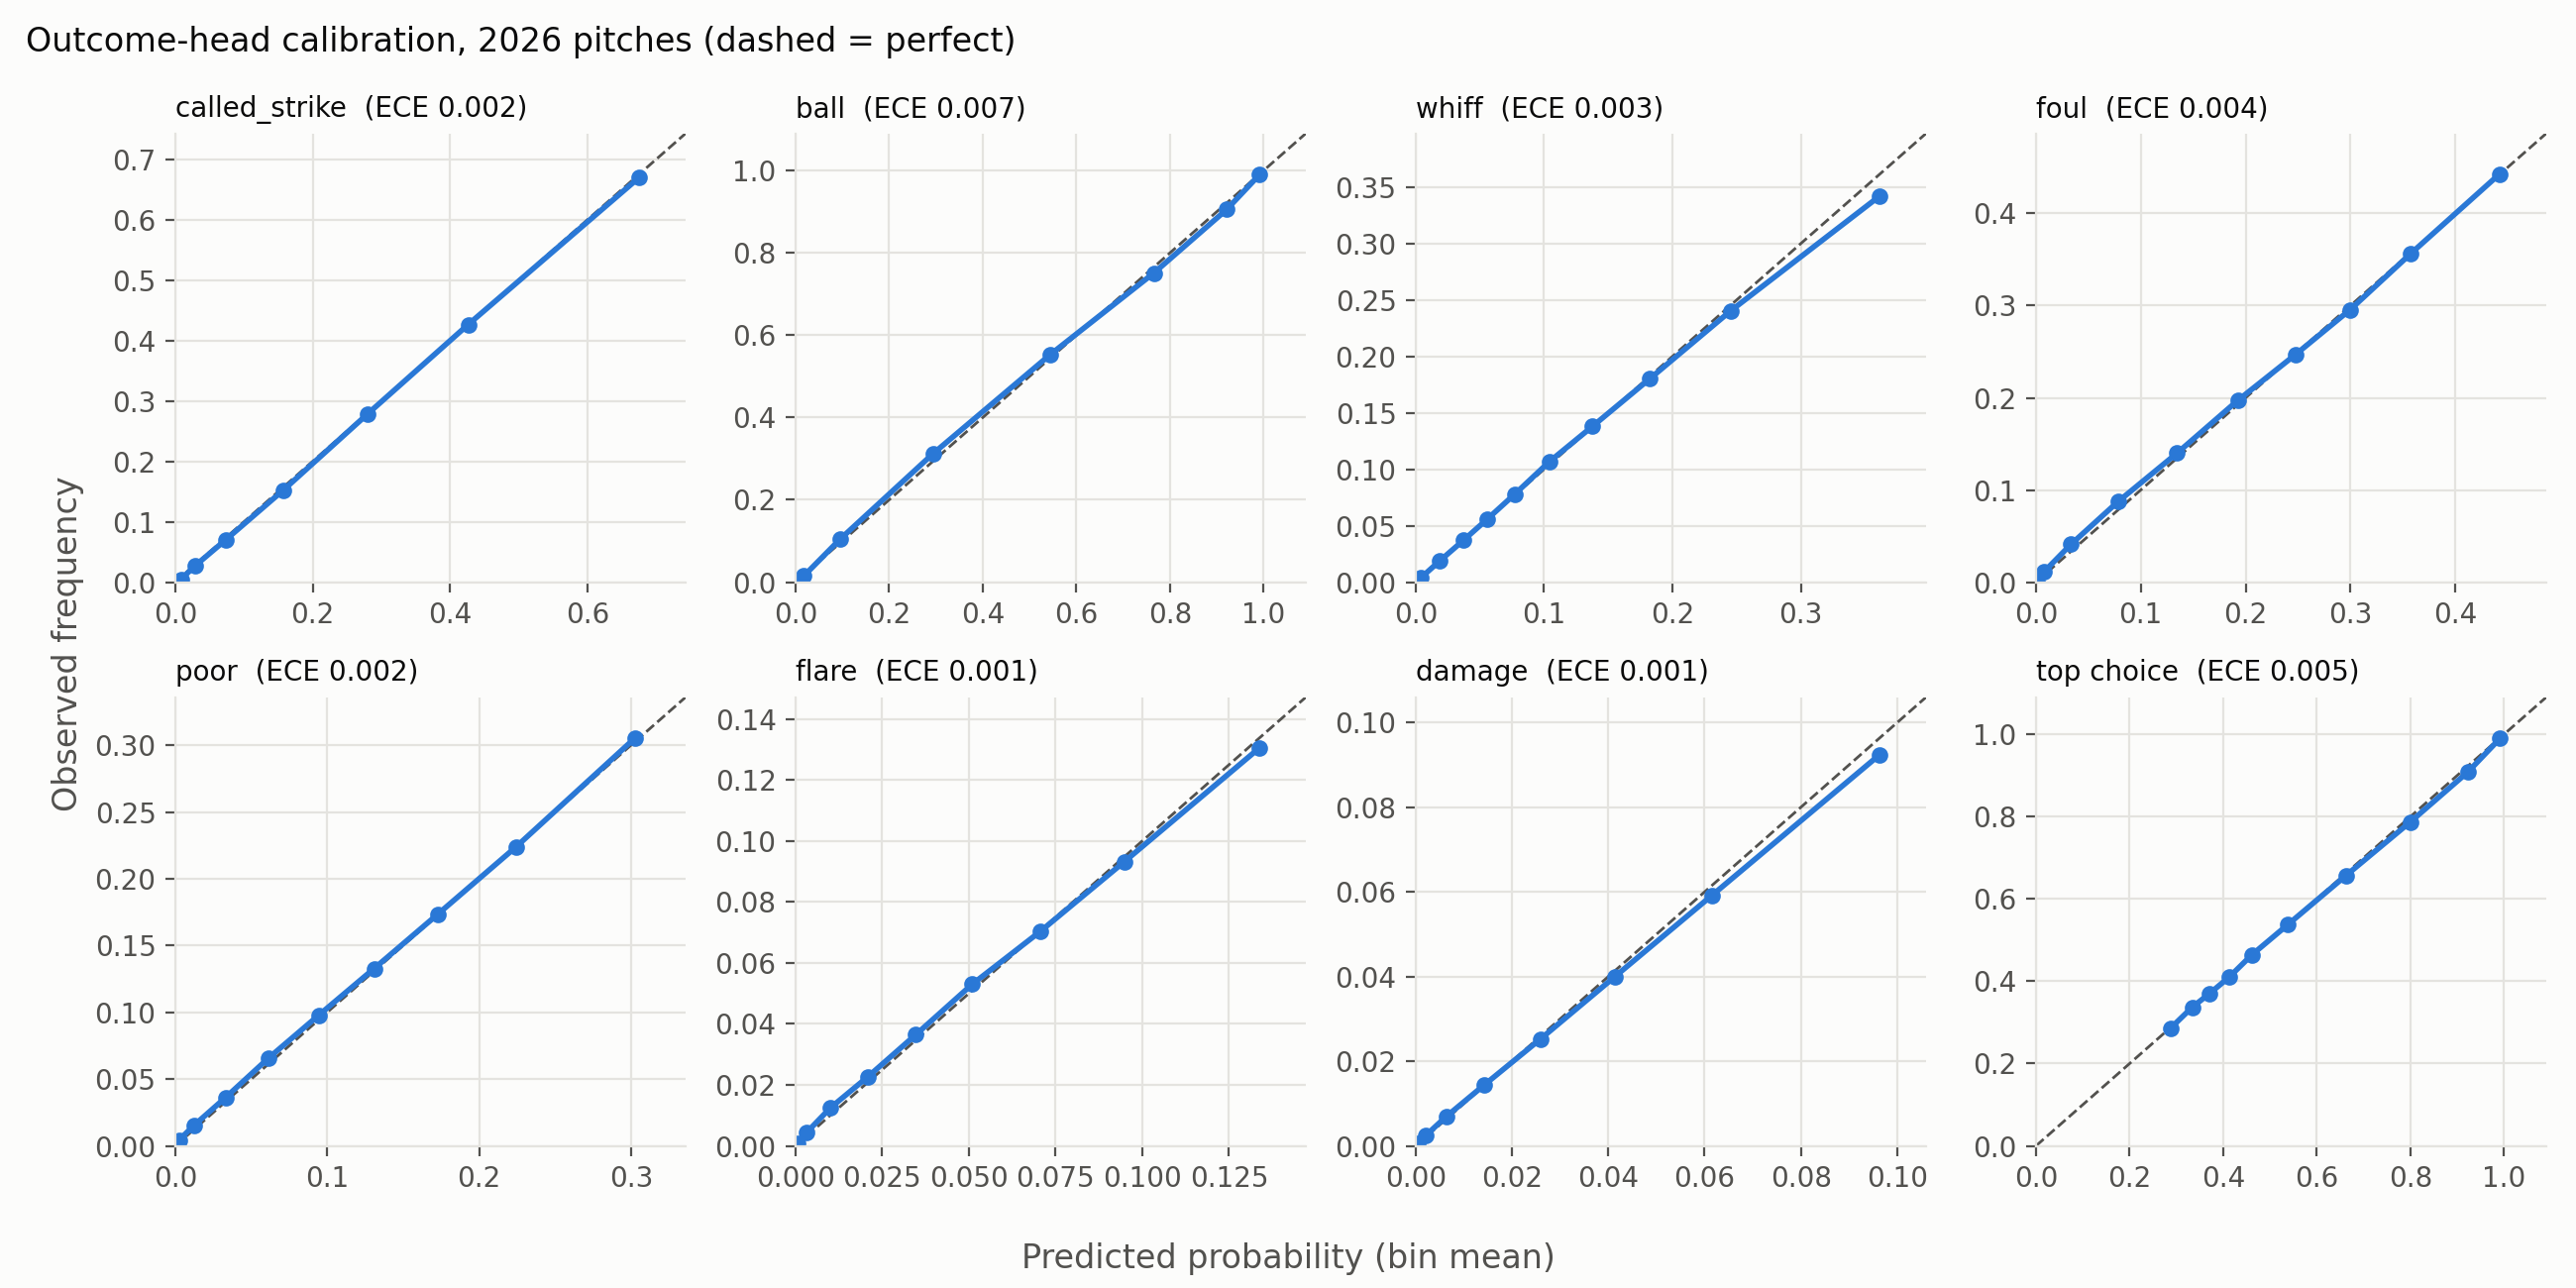

In [9]:
from IPython.display import Image, display

for fig in ["training_curves.png", "stat_breakdown_test.png", "reliability_test.png"]:
    print(fig)
    display(Image(filename=str(FIGURES / fig)))

## 7. What it means

**What replicated in both years.** The learned comps predict walk rate and swing-and-miss better than HZB,
the strongest published formula, and HZB's comps predict ground-ball rate better than ours. Those three are
the findings this project would defend.

**What didn't.** The 2025 edge on overall run value (+0.096, interval above zero) became a tie on 2026
(+0.010, interval crossing zero). The model's choices were all made on 2025, and this is what that costs.

**What the numbers can't support.** On 2026 no method — ours included — beats predicting the pool average on
mean absolute error, so the comps *rank* pitchers better than chance without being a good point prediction.
On pitchers never seen in training, the RV/100 edge disappears entirely. And RV/100's reliability caps any
method near r ≈ 0.53, so the whole comparison happens in a narrow band.

The full list of weaknesses is in the README under *Limitations and known gaps*, each tied to the file that
shows it.